### CNN classifier for the MNIST dataset

This notebook has code to build, compile and fit a convolutional neural network (CNN) model to the MNIST dataset of images of handwritten digits.

##### About Dataset - The MNIST Dataset

The MNIST dataset consists of a training set of 60,000 handwritten digits with corresponding labels, and a test set of 10,000 images. The images have been normalised and centred. The dataset is frequently used in machine learning research, and has become a standard benchmark for image classification models.

In [2]:
#Importing libraries

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

In [3]:
#Loading the dataset

mnist_data = tf.keras.datasets.mnist
(train_images, train_labels), (test_images, test_labels) = mnist_data.load_data()

In [4]:
# function to rescale train and test images

def scale_mnist_data(train_images, test_images):

    train_images = train_images/255.
    test_images = test_images/255.

    return (train_images, test_images)

In [5]:
scaled_train_images, scaled_test_images = scale_mnist_data(train_images, test_images)

In [6]:
scaled_train_images.shape

(60000, 28, 28)

In [ ]:
#Adding a dummy channel dimension

scaled_train_images = scaled_train_images.reshape(scaled_train_images.shape[0],scaled_train_images.shape[1] ,scaled_train_images.shape[2], -1)
scaled_test_images = scaled_test_images[..., np.newaxis]

In [15]:
#Building convolution neural network model function

def get_model(input_shape):

    model = tf.keras.models.Sequential(
        [tf.keras.Input(shape=input_shape),
        tf.keras.layers.Conv2D(kernel_size=3, filters=8, padding="same", activation="relu"),
        tf.keras.layers.MaxPooling2D(2,2),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(units=64, activation="relu"),
        tf.keras.layers.Dense(units=64, activation="relu"),
        tf.keras.layers.Dense(units=10, activation="softmax"),

    ])

    return model



In [16]:
model = get_model(scaled_train_images[0].shape)

In [17]:
#Model summary

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       100,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,306 (411.35 KB)

 Trainable params: 105,306 (411.35 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
#Model compiling function

def compile_model(model):

    model.compile(optimizer="adam",
                  metrics=['accuracy'],
                  loss="sparse_categorical_crossentropy")
    
compile_model(model)    



In [19]:
#Model training function

def train_model(model, scaled_train_images, train_labels):

    history = model.fit(scaled_train_images, train_labels, epochs=5)
    return history

In [20]:
history = train_model(model, scaled_train_images, train_labels)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9409 - loss: 0.2002
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9790 - loss: 0.0691
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9847 - loss: 0.0482
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9881 - loss: 0.0359
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9913 - loss: 0.0272


In [22]:
#Getting model history into pandas dataframe

dataframe = pd.DataFrame(history.history)
dataframe

,accuracy,loss
0,0.940917,0.200186
1,0.979033,0.069073
2,0.984750,0.048176
3,0.988133,0.035858
4,0.991300,0.027171


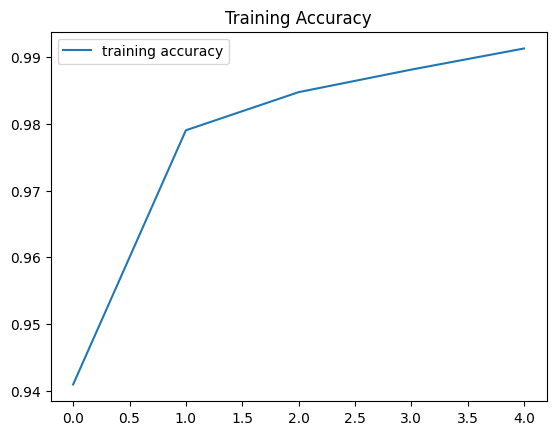

In [31]:
plt.plot(history.history['accuracy'], label="training accuracy")
plt.title("Training Accuracy")
plt.legend()
plt.show()

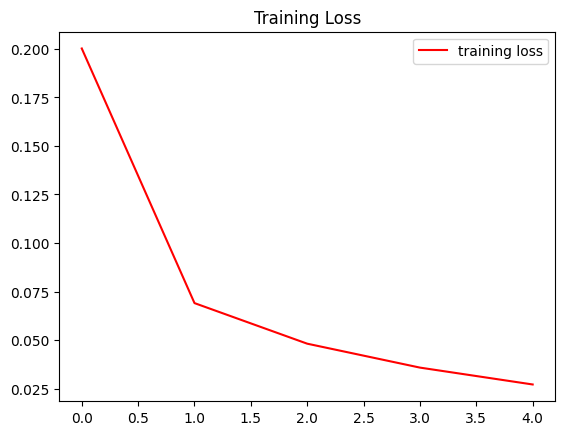

In [34]:
plt.plot(history.history['loss'], "r", label="training loss")
plt.title("Training Loss")
plt.legend()
plt.show()

In [35]:
#Evaluation of the model

def evaluate_model(model, scaled_test_images, test_labels):

    test_loss, test_accuracy = model.evaluate(scaled_test_images, test_labels)

    return (test_loss, test_accuracy)

In [36]:
 test_loss, test_accuracy = evaluate_model(model, scaled_test_images, test_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9834 - loss: 0.0530
